In [6]:
import sys
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join('..')))
from src.features import aggregate_trip

df = pd.read_csv('../data/raw/telemetry.csv')

trip_features = df.groupby('vehicleId').apply(aggregate_trip).reset_index()

os.makedirs('../data/processed', exist_ok=True)
trip_features.to_csv('../data/processed/trip_features.csv', index=False)
print("Saved features to data/processed/trip_features.csv")

Saved features to data/processed/trip_features.csv


Text(0.5, 1.0, 'Distribution of Average Speed')

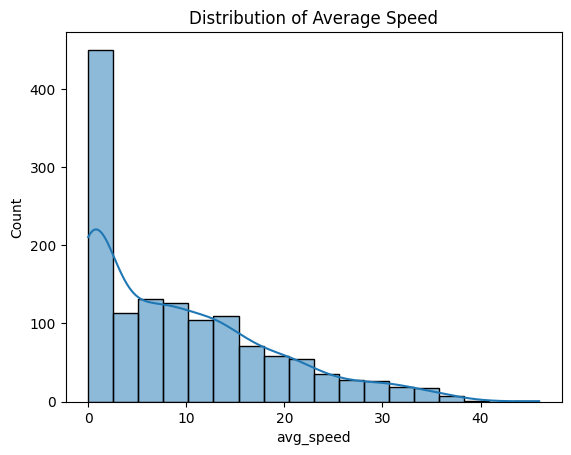

In [17]:
sns.histplot(trip_features['avg_speed'], kde=True)
plt.title('Distribution of Average Speed')

Text(0.5, 1.0, 'Hard Braking Event Counts')

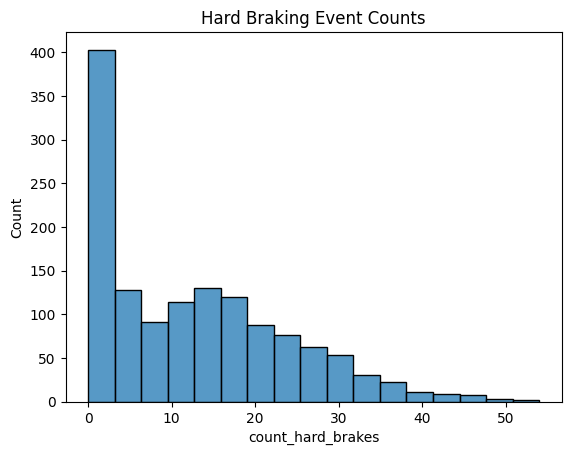

In [16]:
sns.histplot(trip_features['count_hard_brakes'])
plt.title('Hard Braking Event Counts')

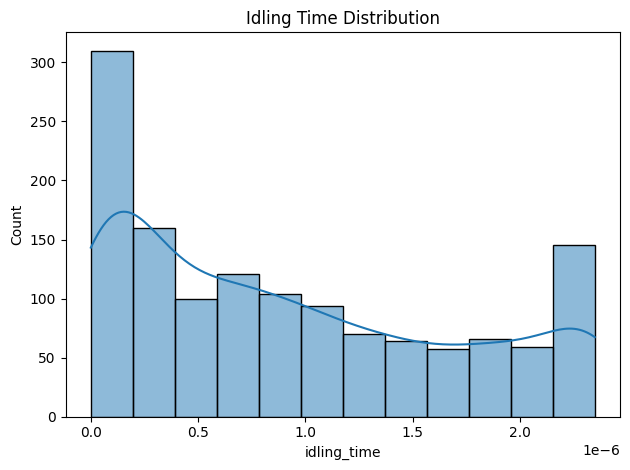

In [11]:
sns.histplot(trip_features['idling_time'], kde=True)
plt.title('Idling Time Distribution')
plt.tight_layout()
plt.show()

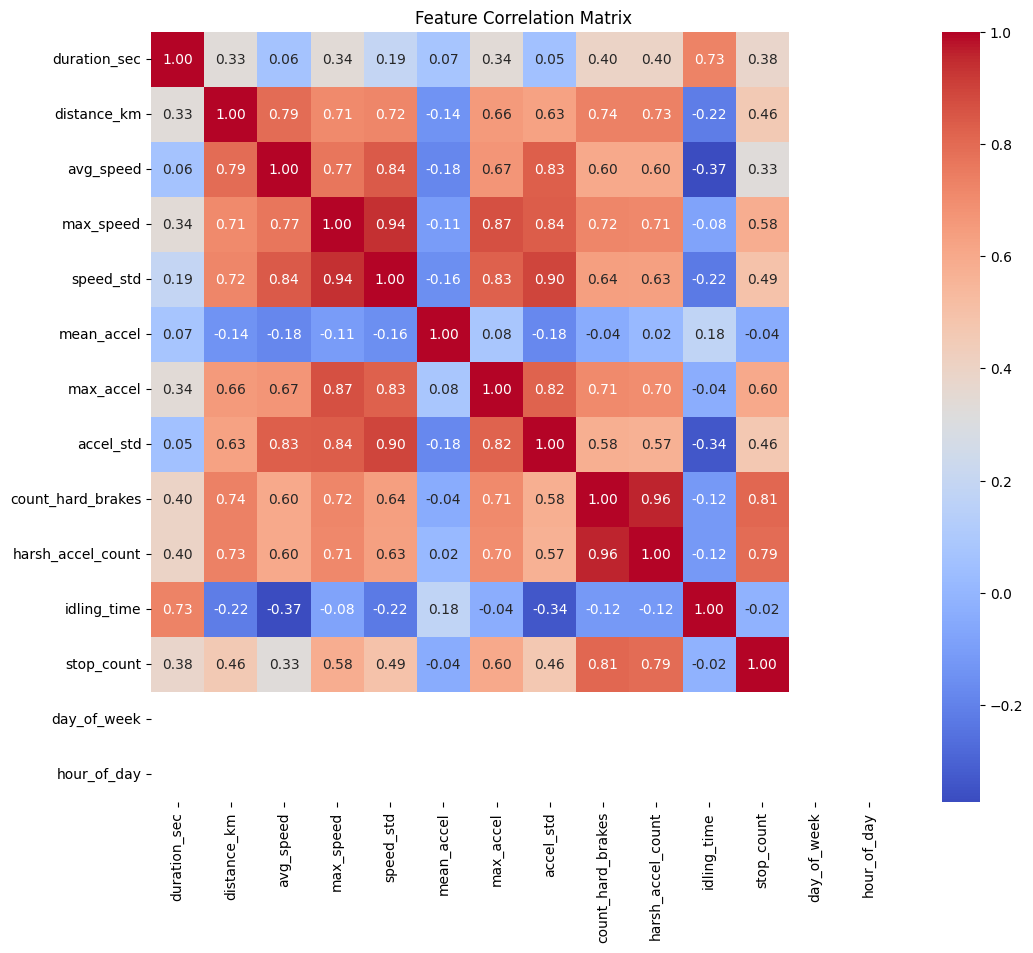

In [10]:
plt.figure(figsize=(12, 10))
corr = trip_features.drop(columns=['vehicleId']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()